In [ ]:
!python --version

Python 3.12.12


# IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import os

In [2]:
# Mount to Google Drive
drive.mount('/content/drive')

# Masuk ke folder Thesis Ardi
path = '/content/drive/MyDrive/Thesis Ardi'
os.chdir(path)

Mounted at /content/drive


# DATASET 1

In [ ]:
# Read Dataset
df_1 = pd.read_csv('Data Thesis/Dataset CHEMBL3024.csv', sep=';')
df_1.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value
0,CHEMBL606410,NaN,NaN,346.39,0.0,3.78,28i,CCOc1ccc(Nc2ncc3c(n2)-c2ccccc2NC(=O)C3)cc1,IC50,'>',...,SINGLE PROTEIN,CHEMBL1157616,1,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN
1,CHEMBL598633,NaN,NaN,319.32,0.0,2.48,31g,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,IC50,'=',...,SINGLE PROTEIN,CHEMBL1157616,1,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN
2,CHEMBL606185,NaN,NaN,319.32,0.0,2.48,31j,O=C1Cc2cnc(Nc3cccc(O)c3)nc2-c2ncccc2N1,IC50,'>',...,SINGLE PROTEIN,CHEMBL1157616,1,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN
3,CHEMBL483531,ALTENUSIN,NaN,290.27,0.0,2.49,6,COc1cc(O)c(C(=O)O)c(-c2cc(O)c(O)cc2C)c1,IC50,'=',...,SINGLE PROTEIN,CHEMBL1157406,1,Scientific Literature,J Nat Prod,2008,NaN,NaN,NaN,NaN
4,CHEMBL514371,NaN,NaN,425.51,0.0,0.10,5,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,IC50,'=',...,SINGLE PROTEIN,CHEMBL1144187,1,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN


In [ ]:
# Filter data "Standard Units == nM" dan "Standard Relation == '='"
df_1_filter = df_1[(df_1['Standard Units'] == "nM") & (df_1['Standard Relation'] == "'='")]
df_1_filter.reset_index(drop=True, inplace=True)
df_1_filter.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value
0,CHEMBL598633,NaN,NaN,319.32,0.0,2.48,31g,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,IC50,'=',...,SINGLE PROTEIN,CHEMBL1157616,1,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN
1,CHEMBL514371,NaN,NaN,425.51,0.0,0.10,5,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,IC50,'=',...,SINGLE PROTEIN,CHEMBL1144187,1,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN
2,CHEMBL492008,NaN,NaN,264.22,0.0,0.41,37,N#Cc1cc([N+](=O)[O-])c2sc(C(N)=O)[n+]([O-])c2c1,IC50,'=',...,SINGLE PROTEIN,CHEMBL1144187,1,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN
3,CHEMBL454196,NaN,NaN,363.44,0.0,4.07,9,Cc1ccc(COc2cc(-n3cnc4ccccc43)sc2C(N)=O)cc1,IC50,'=',...,SINGLE PROTEIN,CHEMBL1143265,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN
4,CHEMBL481492,NaN,NaN,397.89,0.0,4.73,19,Cc1ccccc1COc1cc(-n2cnc3cc(Cl)ccc32)sc1C(N)=O,IC50,'=',...,SINGLE PROTEIN,CHEMBL1143265,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN


## Preprocessing Dataset 1

In [ ]:
# Cek tipe data
df_1_filter.dtypes

,0
Molecule ChEMBL ID,object
Molecule Name,object
Molecule Max Phase,float64
Molecular Weight,float64
#RO5 Violations,float64
AlogP,float64
Compound Key,object
Smiles,object
Standard Type,object
Standard Relation,object


In [ ]:
# Cek duplikat data
df_1_filter.duplicated().sum()

np.int64(0)

## Buat Label Dataset 1

In [ ]:
# Membuat Kolom PIC50
df_1_filter['PIC50'] = -np.log10(df_1_filter['Standard Value'] * 1e-9)
df_1_filter.head()

/tmp/ipython-input-2446624834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1_filter['PIC50'] = -np.log10(df_1_filter['Standard Value'] * 1e-9)


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,PIC50
0,CHEMBL598633,NaN,NaN,319.32,0.0,2.48,31g,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,IC50,'=',...,CHEMBL1157616,1,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN,4.259637
1,CHEMBL514371,NaN,NaN,425.51,0.0,0.10,5,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,IC50,'=',...,CHEMBL1144187,1,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,7.148742
2,CHEMBL492008,NaN,NaN,264.22,0.0,0.41,37,N#Cc1cc([N+](=O)[O-])c2sc(C(N)=O)[n+]([O-])c2c1,IC50,'=',...,CHEMBL1144187,1,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,5.000000
3,CHEMBL454196,NaN,NaN,363.44,0.0,4.07,9,Cc1ccc(COc2cc(-n3cnc4ccccc43)sc2C(N)=O)cc1,IC50,'=',...,CHEMBL1143265,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.154902
4,CHEMBL481492,NaN,NaN,397.89,0.0,4.73,19,Cc1ccccc1COc1cc(-n2cnc3cc(Cl)ccc32)sc1C(N)=O,IC50,'=',...,CHEMBL1143265,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.677781


In [ ]:
# Menghitung Mean PIC50
mean_pic50 = df_1_filter['PIC50'].mean()
print("Mean pIC50 : ", mean_pic50)

Mean pIC50 :  6.499720212984649


In [ ]:
# Membuat Label Pada Dataset, Jika Nilai pIC50 > mean Maka 1, Selain Itu 0
df_1_filter['Label'] = np.where(df_1_filter['PIC50'] > mean_pic50, 1, 0)
df_1_filter.head()

/tmp/ipython-input-1208162185.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1_filter['Label'] = np.where(df_1_filter['PIC50'] > mean_pic50, 1, 0)


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,PIC50,Label
0,CHEMBL598633,NaN,NaN,319.32,0.0,2.48,31g,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,IC50,'=',...,1,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN,4.259637,0
1,CHEMBL514371,NaN,NaN,425.51,0.0,0.10,5,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,IC50,'=',...,1,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,7.148742,1
2,CHEMBL492008,NaN,NaN,264.22,0.0,0.41,37,N#Cc1cc([N+](=O)[O-])c2sc(C(N)=O)[n+]([O-])c2c1,IC50,'=',...,1,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,5.000000,0
3,CHEMBL454196,NaN,NaN,363.44,0.0,4.07,9,Cc1ccc(COc2cc(-n3cnc4ccccc43)sc2C(N)=O)cc1,IC50,'=',...,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.154902,1
4,CHEMBL481492,NaN,NaN,397.89,0.0,4.73,19,Cc1ccccc1COc1cc(-n2cnc3cc(Cl)ccc32)sc1C(N)=O,IC50,'=',...,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.677781,1


Label
0    635
1    582
Name: count, dtype: int64


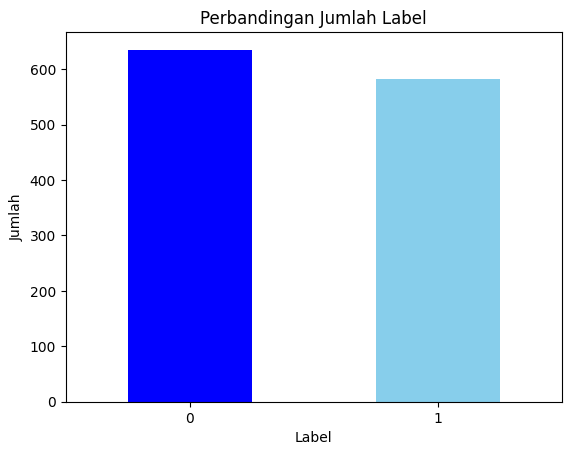

In [ ]:
# Menghitung jumlah label dan visualisasi

label_count = df_1_filter['Label'].value_counts()
print(label_count)

label_count.plot(kind='bar', color=['blue', 'skyblue'])
plt.title("Perbandingan Jumlah Label")
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

## Hitung Panjang Smiles Dataset 1

In [ ]:
# Hitung panjang smiles
df_1_new= df_1_filter.copy()

# Buat Kolom Baru Untuk Hitung Panjang SMiles
df_1_new['Panjang'] = df_1_new['Smiles'].str.len()
df_1_new.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,PIC50,Label,Panjang
0,CHEMBL598633,NaN,NaN,319.32,0.0,2.48,31g,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,IC50,'=',...,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN,4.259637,0,38
1,CHEMBL514371,NaN,NaN,425.51,0.0,0.10,5,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,7.148742,1,56
2,CHEMBL492008,NaN,NaN,264.22,0.0,0.41,37,N#Cc1cc([N+](=O)[O-])c2sc(C(N)=O)[n+]([O-])c2c1,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,5.000000,0,47
3,CHEMBL454196,NaN,NaN,363.44,0.0,4.07,9,Cc1ccc(COc2cc(-n3cnc4ccccc43)sc2C(N)=O)cc1,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.154902,1,42
4,CHEMBL481492,NaN,NaN,397.89,0.0,4.73,19,Cc1ccccc1COc1cc(-n2cnc3cc(Cl)ccc32)sc1C(N)=O,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.677781,1,44


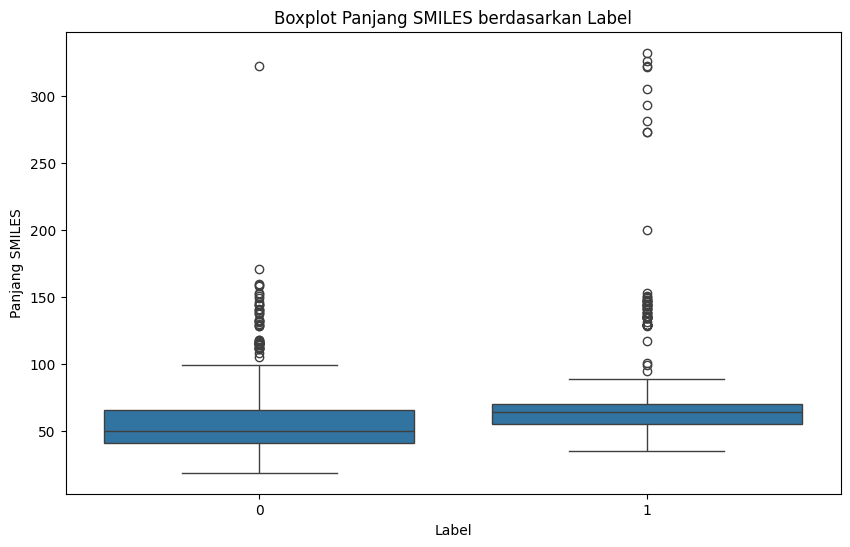

In [ ]:
# Membuat Boxplot Panjang SMILES
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='Panjang', data=df_1_new)
plt.title('Boxplot Panjang SMILES berdasarkan Label')
plt.xlabel('Label')
plt.ylabel('Panjang SMILES')
plt.show()

In [ ]:
# Lihat statistik deskriptif dataset 1
df_1_new['Panjang'].describe()

,Panjang
count,1217.000000
mean,64.346754
std,33.753699
min,19.000000
25%,46.000000
50%,59.000000
75%,69.000000
max,332.000000


In [ ]:
# Menghitung Interquartile
Q1 = df_1_new['Panjang'].quantile(0.25)
Q3 = df_1_new['Panjang'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 : ", Q1)
print("Q3 : ", Q3)
print("Interquartile Range (IQR) :", IQR)

# Menghitung Upper Threshold
upper_threshold = Q3 + 1.5 * IQR
print("Upper Threshold :", upper_threshold)

# Menghitung Lower Threshold
lower_threshold = Q1 - 1.5 * IQR
print("Lower Threshold :", lower_threshold)

Q1 :  46.0
Q3 :  69.0
Interquartile Range (IQR) : 23.0
Upper Threshold : 103.5
Lower Threshold : 11.5


## Buat Dataset Baru Dari Filter Panjang Smiles

In [ ]:
# Dataset 1 (Lower sampai Upper = 12 sampai 104)
dataset_1 = df_1_new[(df_1_new['Panjang'] >= 12) & (df_1_new['Panjang'] <= 104)]
dataset_1.reset_index(drop=True, inplace=True)
print("Sum of dataset_1 :", len(dataset_1))
dataset_1.head()

Sum of dataset_1 : 1105


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,PIC50,Label,Panjang
0,CHEMBL598633,NaN,NaN,319.32,0.0,2.48,31g,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,IC50,'=',...,Scientific Literature,J Med Chem,2010,NaN,NaN,NaN,NaN,4.259637,0,38
1,CHEMBL514371,NaN,NaN,425.51,0.0,0.10,5,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,7.148742,1,56
2,CHEMBL492008,NaN,NaN,264.22,0.0,0.41,37,N#Cc1cc([N+](=O)[O-])c2sc(C(N)=O)[n+]([O-])c2c1,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2008,NaN,NaN,NaN,NaN,5.000000,0,47
3,CHEMBL454196,NaN,NaN,363.44,0.0,4.07,9,Cc1ccc(COc2cc(-n3cnc4ccccc43)sc2C(N)=O)cc1,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.154902,1,42
4,CHEMBL481492,NaN,NaN,397.89,0.0,4.73,19,Cc1ccccc1COc1cc(-n2cnc3cc(Cl)ccc32)sc1C(N)=O,IC50,'=',...,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,7.677781,1,44


In [ ]:
# Ambil kolom smiles dan label
dataset_1 = dataset_1[['Smiles', 'Label']]
dataset_1.head()

,Smiles,Label
0,O=C1Cc2cnc(Nc3ccc(O)cc3)nc2-c2ncccc2N1,0
1,C#CNC(=O)/C(C#N)=c1\s/c(=C/Nc2ccc(OCCN(C)C)cc2...,1
2,N#Cc1cc([N+](=O)[O-])c2sc(C(N)=O)[n+]([O-])c2c1,0
3,Cc1ccc(COc2cc(-n3cnc4ccccc43)sc2C(N)=O)cc1,1
4,Cc1ccccc1COc1cc(-n2cnc3cc(Cl)ccc32)sc1C(N)=O,1


In [ ]:
dataset_1.shape

(1105, 2)

In [ ]:
# Save to csv
dataset_1.to_csv('Dataset Thesis/Dataset 1.csv', index=False)

In [ ]:
df_1_mentah = df_1_new[['Smiles', 'Label', 'Panjang']]
df_1_mentah.to_csv('Dataset Thesis/Data 1 Mentah.csv', index=False)

# DATASET 2

In [ ]:
# Read dataset
df_2 = pd.read_csv('Data Thesis/Dataset_plk1_baru.csv')
df_2.head()

,mol,pic50,smiles
0,CHEMBL103667,4.522879,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...
1,CHEMBL1087397,5.698970,CN(C)Cc1ccc(-c2cnn3c(-c4cccc(NC(=O)c5cccc(C(F)...
2,CHEMBL1087421,5.000000,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2
3,CHEMBL1088633,5.000000,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2
4,CHEMBL1089082,4.301030,O=C(Nc1cccc(-c2ccnc3cc(-c4ccncc4)nn23)c1)c1ccc...


## Preprocessing Dataset 2

In [ ]:
# Cek tipe data
df_2.dtypes

,0
mol,object
pic50,float64
smiles,object


In [ ]:
# Cek duplikat data
df_2.duplicated().sum()

np.int64(0)

## Buat Label Dataset 2

In [ ]:
# Menghitung Mean PIC50
mean_pic50 = df_2['pic50'].mean()
print("Mean pIC50 : ", mean_pic50)

Mean pIC50 :  6.211262842565656


In [ ]:
# Rename beberapa kolom
df_2.rename(columns={'smiles':'Smiles'}, inplace=True)
df_2.head()

,mol,pic50,Smiles
0,CHEMBL103667,4.522879,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...
1,CHEMBL1087397,5.698970,CN(C)Cc1ccc(-c2cnn3c(-c4cccc(NC(=O)c5cccc(C(F)...
2,CHEMBL1087421,5.000000,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2
3,CHEMBL1088633,5.000000,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2
4,CHEMBL1089082,4.301030,O=C(Nc1cccc(-c2ccnc3cc(-c4ccncc4)nn23)c1)c1ccc...


In [ ]:
# Membuat Label Pada Dataset, Jika Nilai pIC50 > mean Maka 1, Selain Itu 0
df_2['Label'] = np.where(df_2['pic50'] > mean_pic50, 1, 0)
df_2.head()

,mol,pic50,Smiles,Label
0,CHEMBL103667,4.522879,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,0
1,CHEMBL1087397,5.698970,CN(C)Cc1ccc(-c2cnn3c(-c4cccc(NC(=O)c5cccc(C(F)...,0
2,CHEMBL1087421,5.000000,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2,0
3,CHEMBL1088633,5.000000,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2,0
4,CHEMBL1089082,4.301030,O=C(Nc1cccc(-c2ccnc3cc(-c4ccncc4)nn23)c1)c1ccc...,0


Label
0    508
1    482
Name: count, dtype: int64


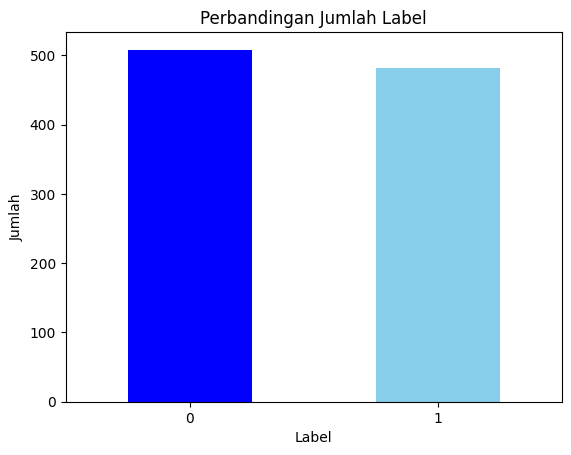

In [ ]:
# Menghitung jumlah label dan visualisasi

label_count = df_2['Label'].value_counts()
print(label_count)

label_count.plot(kind='bar', color=['blue', 'skyblue'])
plt.title("Perbandingan Jumlah Label")
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

## Hitung Panjang Smiles Dataset 2

In [ ]:
# Copy df_filtered
df_2_new = df_2.copy()

# Buat Kolom Baru Untuk Hitung Panjang SMiles
df_2_new['Panjang'] = df_2_new['Smiles'].str.len()
df_2_new.head()

,mol,pic50,Smiles,Label,Panjang
0,CHEMBL103667,4.522879,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,0,63
1,CHEMBL1087397,5.698970,CN(C)Cc1ccc(-c2cnn3c(-c4cccc(NC(=O)c5cccc(C(F)...,0,67
2,CHEMBL1087421,5.000000,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2,0,39
3,CHEMBL1088633,5.000000,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2,0,35
4,CHEMBL1089082,4.301030,O=C(Nc1cccc(-c2ccnc3cc(-c4ccncc4)nn23)c1)c1ccc...,0,59


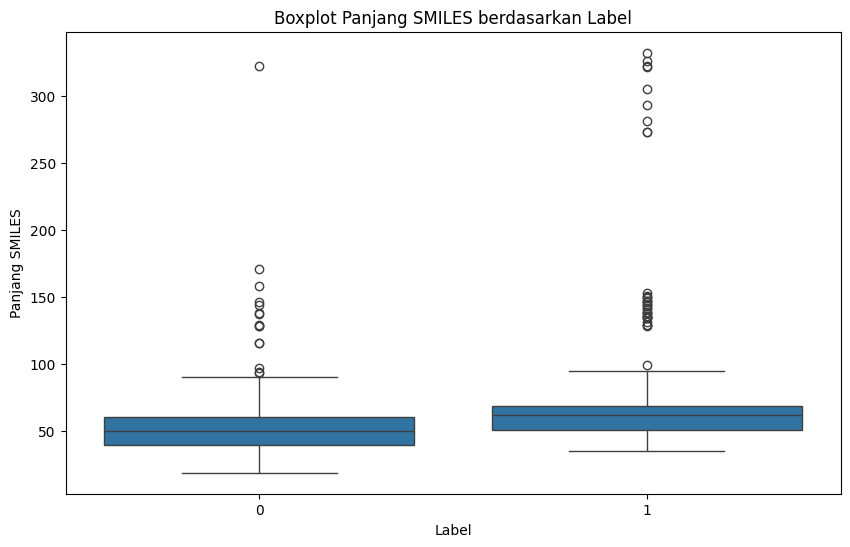

In [ ]:
# Membuat Boxplot Panjang SMILES
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='Panjang', data=df_2_new)
plt.title('Boxplot Panjang SMILES berdasarkan Label')
plt.xlabel('Label')
plt.ylabel('Panjang SMILES')
plt.show()

In [ ]:
# Menghitung Statistik Deskriptif Panjang SMILES berdasarkan Label
df_2_new['Panjang'].describe()

,Panjang
count,990.000000
mean,60.065657
std,32.191552
min,19.000000
25%,46.000000
50%,56.000000
75%,66.000000
max,332.000000


In [ ]:
# Menghitung Interquartile
Q1 = df_2_new['Panjang'].quantile(0.25)
Q3 = df_2_new['Panjang'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 : ", Q1)
print("Q3 : ", Q3)
print("Interquartile Range (IQR) :", IQR)

# Menghitung Upper Threshold
upper_threshold = Q3 + 1.5 * IQR
print("Upper Threshold :", upper_threshold)

# Menghitung Lower Threshold
lower_threshold = Q1 - 1.5 * IQR
print("Lower Threshold :", lower_threshold)


Q1 :  46.0
Q3 :  66.0
Interquartile Range (IQR) : 20.0
Upper Threshold : 96.0
Lower Threshold : 16.0


## Buat Dataset Baru Dari Filter Panjang Smiles

In [ ]:
# Dataset 1 (Lower sampai Upper = 12 sampai 104)
dataset_2 = df_2_new[(df_2_new['Panjang'] >= 12) & (df_2_new['Panjang'] <= 196)]
dataset_2.reset_index(drop=True, inplace=True)
print("Sum of dataset 2 :", len(dataset_2))
dataset_2.head()

Sum of dataset 2 : 980


,mol,pic50,Smiles,Label,Panjang
0,CHEMBL103667,4.522879,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,0,63
1,CHEMBL1087397,5.698970,CN(C)Cc1ccc(-c2cnn3c(-c4cccc(NC(=O)c5cccc(C(F)...,0,67
2,CHEMBL1087421,5.000000,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2,0,39
3,CHEMBL1088633,5.000000,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2,0,35
4,CHEMBL1089082,4.301030,O=C(Nc1cccc(-c2ccnc3cc(-c4ccncc4)nn23)c1)c1ccc...,0,59


In [ ]:
# Ambil kolom smiles dan label
dataset_2 = dataset_2[['Smiles', 'Label']]
dataset_2.head()

,Smiles,Label
0,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,0
1,CN(C)Cc1ccc(-c2cnn3c(-c4cccc(NC(=O)c5cccc(C(F)...,0
2,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2,0
3,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2,0
4,O=C(Nc1cccc(-c2ccnc3cc(-c4ccncc4)nn23)c1)c1ccc...,0


In [ ]:
dataset_2.shape

(980, 2)

In [ ]:
# Save to csv
dataset_2.to_csv('Dataset Thesis/Dataset 2.csv', index=False)

In [ ]:
df_2_mentah = df_2_new[['Smiles', 'Label', 'Panjang']]
df_2_mentah.to_csv('Dataset Thesis/Data 2 Mentah.csv', index=False)

# DATASET 3

In [ ]:
# Read dataset
df_3 = pd.read_csv('Data Thesis/PLK-1-Pubchem-xChemBL.csv')
df_3.head()

,SMILE,IC50,Source
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem


In [ ]:
# Rename beberapa kolom
df_3.rename(columns={'SMILE':'Smiles'}, inplace=True)
df_3.head()

,Smiles,IC50,Source
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem


## Preprocessing Dataset 3

In [ ]:
# Cek tipe data
df_3.dtypes

,0
Smiles,object
IC50,float64
Source,object


In [ ]:
# Cek ukuran data
df_3.shape

(3248, 3)

In [ ]:
# Cek duplikat data
df_3.duplicated().sum()

np.int64(334)

In [ ]:
# Drop duplikat data
df_3.drop_duplicates(inplace=True)
df_3.duplicated().sum()

np.int64(0)

## Buat Label Dataset 3

In [ ]:
# Membuat Kolom PIC50
df_3['PIC50'] = -np.log10(df_3['IC50'] * 1e-9)
df_3.head()

,Smiles,IC50,Source,PIC50
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136


In [ ]:
# Menghitung Mean PIC50
mean_pic50 = df_3['PIC50'].mean()
print("Mean pIC50 : ", mean_pic50)

Mean pIC50 :  6.17692136258801


In [ ]:
# Membuat Label Pada Dataset, Jika Nilai pIC50 > mean Maka 1, Selain Itu 0
df_3['Label'] = np.where(df_3['PIC50'] > mean_pic50, 1, 0)
df_3.head()

,Smiles,IC50,Source,PIC50,Label
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922,1
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940,1
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136,1
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136,1
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136,1


Label
0    1589
1    1325
Name: count, dtype: int64


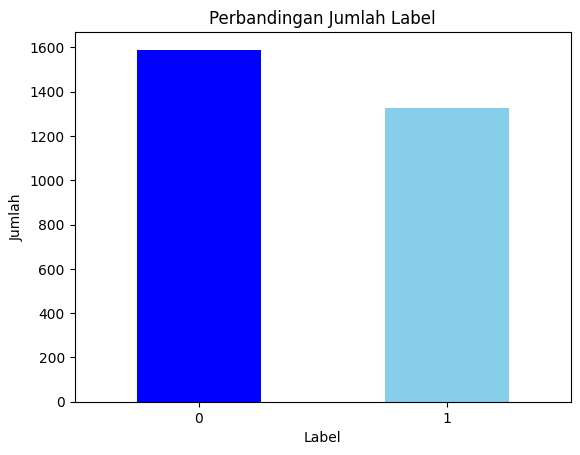

In [ ]:
# Menghitung jumlah label dan visualisasi

label_count = df_3['Label'].value_counts()
print(label_count)

label_count.plot(kind='bar', color=['blue', 'skyblue'])
plt.title("Perbandingan Jumlah Label")
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

## Hitung Panjang Smiles Dataset 3

In [ ]:
# Hitung panjang smiles
df_3_new= df_3.copy()

# Buat Kolom Baru Untuk Hitung Panjang SMiles
df_3_new['Panjang'] = df_3_new['Smiles'].str.len()
df_3_new.head()

,Smiles,IC50,Source,PIC50,Label,Panjang
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922,1,75
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940,1,82
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136,1,79
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136,1,81
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136,1,80


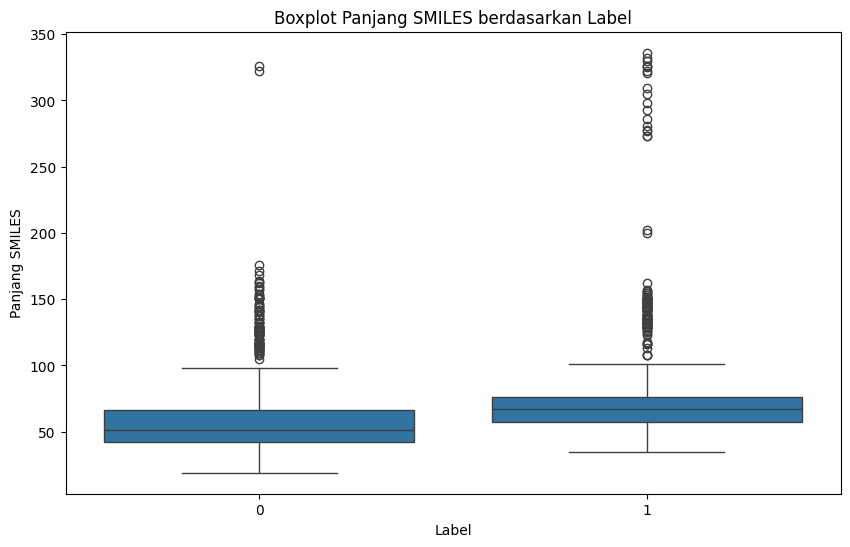

In [ ]:
# Membuat Boxplot Panjang SMILES
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='Panjang', data=df_3_new)
plt.title('Boxplot Panjang SMILES berdasarkan Label')
plt.xlabel('Label')
plt.ylabel('Panjang SMILES')
plt.show()

In [ ]:
# Menghitung Statistik Deskriptif Panjang SMILES berdasarkan Label
df_3_new['Panjang'].describe()

,Panjang
count,2914.000000
mean,65.563487
std,32.549093
min,19.000000
25%,48.000000
50%,60.000000
75%,72.000000
max,336.000000


In [ ]:
# Menghitung Interquartile
Q1 = df_3_new['Panjang'].quantile(0.25)
Q3 = df_3_new['Panjang'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 : ", Q1)
print("Q3 : ", Q3)
print("Interquartile Range (IQR) :", IQR)

# Menghitung Upper Threshold
upper_threshold = Q3 + 1.5 * IQR
print("Upper Threshold :", upper_threshold)

# Menghitung Lower Threshold
lower_threshold = Q1 - 1.5 * IQR
print("Lower Threshold :", lower_threshold)

Q1 :  48.0
Q3 :  72.0
Interquartile Range (IQR) : 24.0
Upper Threshold : 108.0
Lower Threshold : 12.0


## Buat Dataset Baru Dari Filter Panjang Smiles

In [ ]:
# Dataset 1 (Lower sampai Upper = 12 sampai 104)
dataset_3 = df_3_new[(df_3_new['Panjang'] >= 12) & (df_3_new['Panjang'] <= 108)]
dataset_3.reset_index(drop=True, inplace=True)
print("Sum of dataset 3 :", len(dataset_3))
dataset_3.head()

Sum of dataset 3 : 2666


,Smiles,IC50,Source,PIC50,Label,Panjang
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922,1,75
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940,1,82
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136,1,79
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136,1,81
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136,1,80


In [ ]:
# Ambil kolom smiles dan label
dataset_3 = dataset_3[['Smiles', 'Label']]
dataset_3.head()

,Smiles,Label
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,1
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,1
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,1
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,1
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,1


Label
0    1479
1    1187
Name: count, dtype: int64


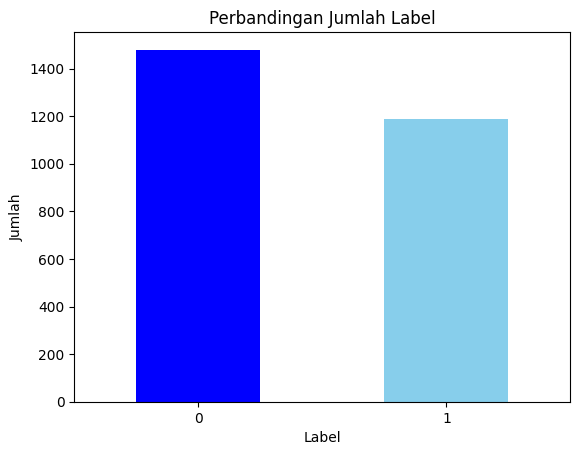

In [ ]:
# Menghitung jumlah label dan visualisasi

label_count = dataset_3['Label'].value_counts()
print(label_count)

label_count.plot(kind='bar', color=['blue', 'skyblue'])
plt.title("Perbandingan Jumlah Label")
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

In [ ]:
dataset_3.shape

(2666, 2)

In [ ]:
# Save to csv
dataset_3.to_csv('Dataset Thesis/Dataset 3.csv', index=False)

In [ ]:
df_3_mentah = df_3_new[['Smiles', 'Label', 'Panjang']]
df_3_mentah.to_csv('Dataset Thesis/Data 3 Mentah.csv', index=False)

In [ ]:
# # --- 1. Baca ketiga file spreadsheet ---
# data1 = dataset_1.copy()
# data2 = dataset_2.copy()
# data3 = dataset_3.copy()

# # --- 2. Gabungkan semua menjadi satu dataframe ---
# combined = pd.concat([data1, data2, data3], ignore_index=True)

# # --- 3. Cek duplikasi berdasarkan kolom SMILES ---
# dupes = combined[combined.duplicated(subset='Smiles', keep=False)]

# print(f"Total duplikasi antar tiga file: {dupes.shape[0]}")
# print("Contoh data duplikat:")
# print(dupes.head())

# # --- 4. (Opsional) lihat dari file mana data duplikat berasal ---
# data1['source'] = 'data1'
# data2['source'] = 'data2'
# data3['source'] = 'data3'

# combined_src = pd.concat([data1, data2, data3], ignore_index=True)
# dupes_src = combined_src[combined_src.duplicated(subset='Smiles', keep=False)]

# print("\nDuplikasi beserta asal filenya:")
# print(dupes_src.sort_values('Smiles'))

# dupes_src.to_excel('duplikasi_smiles.xlsx', index=False)

# DATASET FIX

In [3]:
# Read dataset
df_fix = pd.read_csv('Data Thesis/PLK-1-Pubchem-xChemBL.csv')
df_fix.head()

,SMILE,IC50,Source
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem


In [4]:
# Rename beberapa kolom
df_fix.rename(columns={'SMILE':'Smiles'}, inplace=True)
df_fix

,Smiles,IC50,Source
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem
...,...,...,...
3243,CCCCCCCCSc1ccc(C(=O)Nc2ccc(C)cc2C(=O)O)cc1,26800.000,CHEMBL
3244,CC[C@@H]1C(=O)N(C)c2cnc(N(C)c3ccc(-c4nc5c(C(N)...,2028.000,CHEMBL
3245,CCCCCCCCc1ccc(C(=O)Nc2ccc(OC)cc2C(=O)O)cc1,5900.000,CHEMBL
3246,C[C@@]12CN(Cc3cccc(C#N)c3)C[C@@](C)(C1)c1c(-c3...,17900.000,CHEMBL


## Preprocessing Dataset 3

In [5]:
# Cek tipe data
df_fix.dtypes

,0
Smiles,object
IC50,float64
Source,object


In [6]:
# Cek ukuran data
df_fix.shape

(3248, 3)

In [7]:
# Cek duplikat data
df_fix.duplicated().sum()

np.int64(334)

In [8]:
# Drop duplikat data
df_fix.drop_duplicates(inplace=True)
df_fix.duplicated().sum()

np.int64(0)

## Buat Label Dataset 3

In [9]:
# Membuat Kolom PIC50
df_fix['PIC50'] = -np.log10(df_fix['IC50'] * 1e-9)
df_fix.head()

,Smiles,IC50,Source,PIC50
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136


In [10]:
# Membuat Label Pada Dataset, Jika Nilai pIC50 > mean Maka 1, Selain Itu 0
df_fix['Label'] = np.where(df_fix['PIC50'] > 6, 1, 0)
df_fix


,Smiles,IC50,Source,PIC50,Label
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922,1
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940,1
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136,1
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136,1
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136,1
...,...,...,...,...,...
3243,CCCCCCCCSc1ccc(C(=O)Nc2ccc(C)cc2C(=O)O)cc1,26800.000,CHEMBL,4.571865,0
3244,CC[C@@H]1C(=O)N(C)c2cnc(N(C)c3ccc(-c4nc5c(C(N)...,2028.000,CHEMBL,5.692932,0
3245,CCCCCCCCc1ccc(C(=O)Nc2ccc(OC)cc2C(=O)O)cc1,5900.000,CHEMBL,5.229148,0
3246,C[C@@]12CN(Cc3cccc(C#N)c3)C[C@@](C)(C1)c1c(-c3...,17900.000,CHEMBL,4.747147,0


Label
0    1484
1    1430
Name: count, dtype: int64


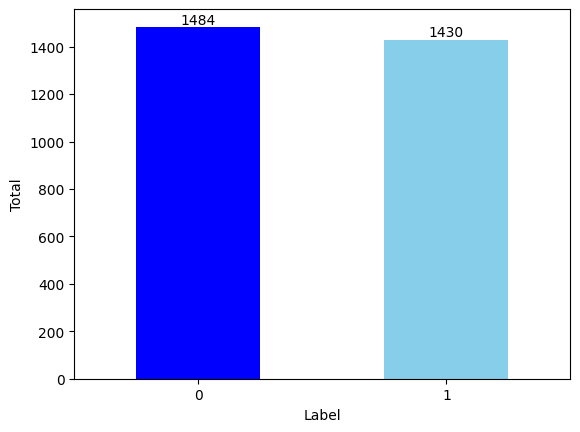

In [11]:
label_count = df_fix['Label'].value_counts()
print(label_count)

# Membuat plot
ax = label_count.plot(kind='bar', color=['blue', 'skyblue'])

# Menambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# plt.title("Perbandingan Jumlah Label")
plt.xlabel('Label')
plt.ylabel('Total')
plt.xticks(rotation=0)
plt.show()

## Hitung Panjang Smiles Dataset 3

In [12]:
# Hitung panjang smiles
df_new= df_fix.copy()

# Buat Kolom Baru Untuk Hitung Panjang SMiles
df_new['Panjang'] = df_new['Smiles'].str.len()
df_new.head()

,Smiles,IC50,Source,PIC50,Label,Panjang
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922,1,75
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940,1,82
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136,1,79
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136,1,81
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136,1,80


In [13]:
df_pendek = df_new[df_new['Panjang'] <= 19]
df_pendek

,Smiles,IC50,Source,PIC50,Label,Panjang
1977,CNC(=O)c1ccc(OC)cc1,125000.0,CHEMBL,3.903090,0,19
2187,CCc1ccc(C(=O)NC)cc1,16500.0,CHEMBL,4.782516,0,19
2278,CNC(=O)c1ccc(NC)cc1,31200.0,CHEMBL,4.505845,0,19
3117,CNC(=O)c1ccc(SC)cc1,18500.0,CHEMBL,4.732828,0,19


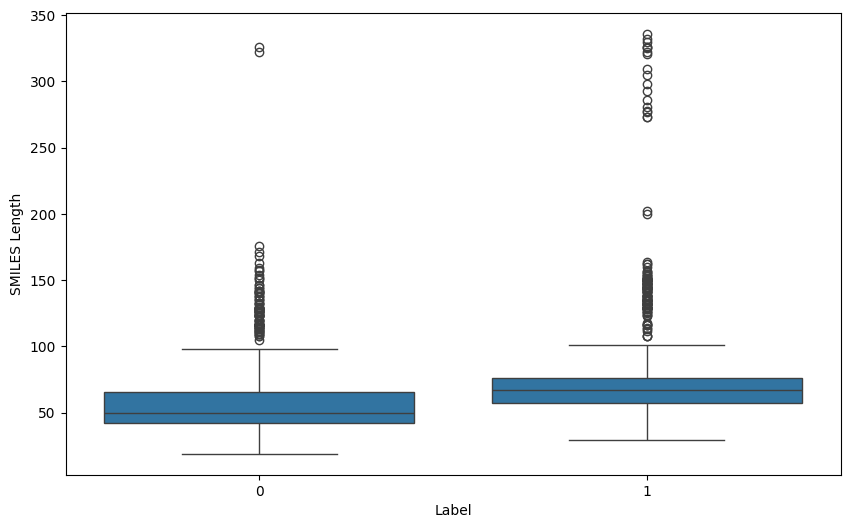

In [14]:
# Membuat Boxplot Panjang SMILES
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='Panjang', data=df_new)
# plt.title('Boxplot Length of SMILES based on Label')
plt.xlabel('Label')
plt.ylabel('SMILES Length')
plt.show()

In [15]:
# Menghitung Statistik Deskriptif Panjang SMILES berdasarkan Label
df_new['Panjang'].describe()

,Panjang
count,2914.000000
mean,65.563487
std,32.549093
min,19.000000
25%,48.000000
50%,60.000000
75%,72.000000
max,336.000000


In [16]:
# Menghitung Interquartile
Q1 = df_new['Panjang'].quantile(0.25)
Q3 = df_new['Panjang'].quantile(0.75)
IQR = Q3 - Q1
print("Q1 : ", Q1)
print("Q3 : ", Q3)
print("Interquartile Range (IQR) :", IQR)

# Menghitung Upper Threshold
upper_threshold = Q3 + 1.5 * IQR
print("Upper Threshold :", upper_threshold)

# Menghitung Lower Threshold
lower_threshold = Q1 - 1.5 * IQR
print("Lower Threshold :", lower_threshold)

Q1 :  48.0
Q3 :  72.0
Interquartile Range (IQR) : 24.0
Upper Threshold : 108.0
Lower Threshold : 12.0


## Buat Dataset Baru Dari Filter Panjang Smiles

In [17]:
# Dataset 1 (Lower sampai Upper = 12 sampai 104)
dataset_fix = df_new[(df_new['Panjang'] >= 12) & (df_new['Panjang'] <= 108)]
dataset_fix.reset_index(drop=True, inplace=True)
print("Sum of dataset 3 :", len(dataset_fix))
dataset_fix.head()

Sum of dataset 3 : 2666


,Smiles,IC50,Source,PIC50,Label,Panjang
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,0.083,Pubchem,10.080922,1,75
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,0.400,Pubchem,9.397940,1,82
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,0.508,Pubchem,9.294136,1,79
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,0.508,Pubchem,9.294136,1,81
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,0.508,Pubchem,9.294136,1,80


In [18]:
dataset_fix.to_csv('Dataset Thesis/Datasetbelumfix.csv', index=False)

In [ ]:
# Ambil kolom smiles dan label
dataset_fix = dataset_fix[['Smiles', 'Label']]
dataset_fix.head()

,Smiles,Label
0,CC[C@@H]1C(=O)N(C2=CN=C(N=C2N1C3CCCC3)NC4=C(C=...,1
1,CC[C@@H]1C2=C(N=CN2C3=CN=C(N=C3N1C(C)C)NC4=C(C...,1
2,CN(C)C1CCN(CC1)C2=CC(=C(C=C2)NC3=NC=C(C(=N3)NC...,1
3,CN1CCN(CC1)C2CCN(CC2)C3=CC=C(C=C3)NC4=NC=C(C(=...,1
4,CN(C)CC(=O)N1CCC2=CC(=C(C=C21)NC3=NC=C(C(=N3)N...,1


Label
0    1386
1    1280
Name: count, dtype: int64


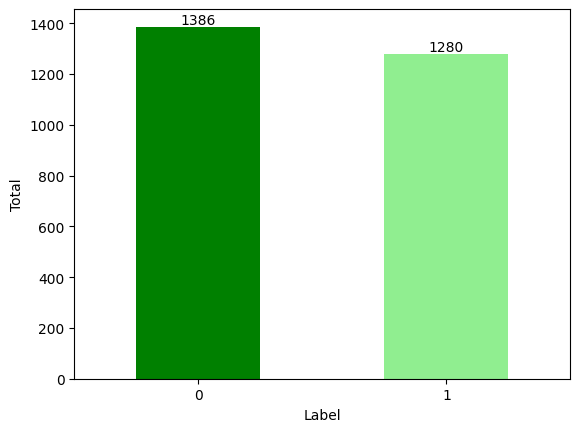

In [ ]:
# Menghitung jumlah label dan visualisasi

label_count = dataset_fix['Label'].value_counts()
print(label_count)

# Membuat plot
ax = label_count.plot(kind='bar', color=['green', 'lightgreen'])

# Menambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# plt.title("Label Distribution")
plt.xlabel('Label')
plt.ylabel('Total')
plt.xticks(rotation=0)
plt.show()

In [ ]:
dataset_fix.shape

(2666, 2)

In [ ]:
# Save to csv
dataset_fix.to_csv('Dataset Thesis/Dataset Fix.csv', index=False)

In [ ]:
# df_3_mentah = df_3_new[['Smiles', 'Label', 'Panjang']]
# df_3_mentah.to_csv('Dataset Thesis/Data 3 Mentah.csv', index=False)

In [ ]:
# # --- 1. Baca ketiga file spreadsheet ---
# data1 = dataset_1.copy()
# data2 = dataset_2.copy()
# data3 = dataset_3.copy()

# # --- 2. Gabungkan semua menjadi satu dataframe ---
# combined = pd.concat([data1, data2, data3], ignore_index=True)

# # --- 3. Cek duplikasi berdasarkan kolom SMILES ---
# dupes = combined[combined.duplicated(subset='Smiles', keep=False)]

# print(f"Total duplikasi antar tiga file: {dupes.shape[0]}")
# print("Contoh data duplikat:")
# print(dupes.head())

# # --- 4. (Opsional) lihat dari file mana data duplikat berasal ---
# data1['source'] = 'data1'
# data2['source'] = 'data2'
# data3['source'] = 'data3'

# combined_src = pd.concat([data1, data2, data3], ignore_index=True)
# dupes_src = combined_src[combined_src.duplicated(subset='Smiles', keep=False)]

# print("\nDuplikasi beserta asal filenya:")
# print(dupes_src.sort_values('Smiles'))

# dupes_src.to_excel('duplikasi_smiles.xlsx', index=False)